# Задание 3

**Часть 1 — Доделываем семинар и получаем SNP:**
В рамках семинара был получен файл с SNP
>"ecoli_full_filt1_snps.tsv".



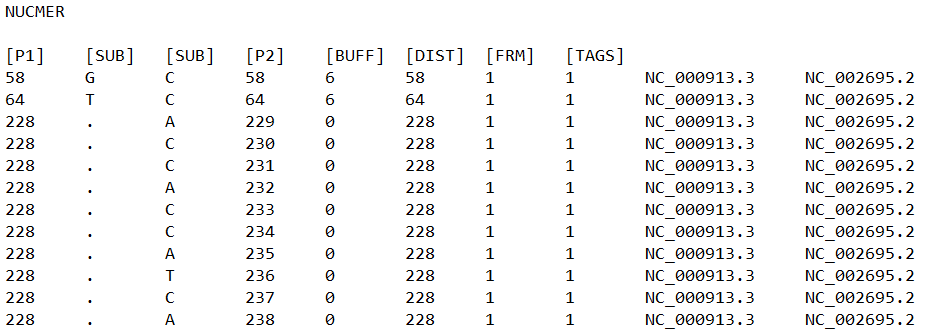

...

Рассмотрим шапку файла и объясним значение каждого из столбцов.


**[P1]	[SUB]	[SUB]	[P2]	[BUFF]	[DIST]	[FRM]	[TAGS]** -  шапка

**[P1]** - Position 1: позиция нуклеотида в референсном геноме (E. coli K-12)

**[SUB]**  (1) - Substitution: тип нуклеотида в референсном геноме (A/T/G/C)

**[SUB]**  (2) - Substitution: тип нуклеотида в референсном сравниваемом геноме (E. coli O157:H7) (A/T/G/C)

**[P2]** - Position 2: позиция нуклеотида в сравниваемом геноме

**[BUFF]** - Buffer: расстояние до близжайшего различия (SNP/indel) геномов

**[DIST]** - Distance: расстояние до конца локального выравнивания

**[FRM]** - Frame: Направление выравнивания (strand): (два предпоследних столбца)
1 → прямое направление (forward strand)
-1 → обратное направление (reverse complement).

**[TAGS]** - Tags: ID геномных последовательностей (последние 2 столбца)






# Часть 2 — Аннотация SNP

Для следующего этапа исследования обратимся к аннотации генов (GenBank файл E. coli K-12).

>wget -O ecoli_k12.gbff.gz https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz

Данный файл содержит такую информацию как: координаты генов, кодирующие последовательности (CDS), направление транскрипции, функциональные характеристики белков. Из этого файла отдельно извлекли информацию о CDS.

> "extract_genes.py" - скрипт:

In [ ]:
import os
import gzip
import pandas as pd
from Bio import SeqIO

# путь к файлу (ЛОКАЛЬНО)

GBFF_PATH = "../data/ecoli_k12.gbff.gz"

# путь к папке с результатами

RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(RESULTS_DIR, "genes_table.tsv")

# загрузка данных из локального файла

def load_genbank_from_file(path: str):
    with gzip.open(path, "rt") as handle:
        record = SeqIO.read(handle, "genbank")
    return record

print("Loading GenBank...")
record = load_genbank_from_file(GBFF_PATH)

print("Loaded:", record.id)
print("Genome length:", len(record.seq))

# извлечение CDS генов

genes = []

for feature in record.features:
    if feature.type == "CDS":

        # координаты
        start = int(feature.location.start)
        end = int(feature.location.end)
        strand = feature.location.strand if feature.location.strand else 0

        # аннотации
        gene_name = feature.qualifiers.get("gene", ["unknown"])[0]
        locus_tag = feature.qualifiers.get("locus_tag", [""])[0]
        product = feature.qualifiers.get("product", [""])[0]

        genes.append({
            "gene": gene_name,
            "locus_tag": locus_tag,
            "start": start,
            "end": end,
            "strand": strand,
            "product": product
        })

genes_df = pd.DataFrame(genes)

# сортировка по координате
genes_df = genes_df.sort_values("start").reset_index(drop=True)

# сохранение

genes_df.to_csv(OUTPUT_PATH, sep="\t", index=False)

print("\nDone!")
print("Genes extracted:", genes_df.shape)
print("Saved to:", OUTPUT_PATH)
print("\nPreview:")
print(genes_df.head())


Результат работы скрипта помещен в файл
> "genes_table.tsv"

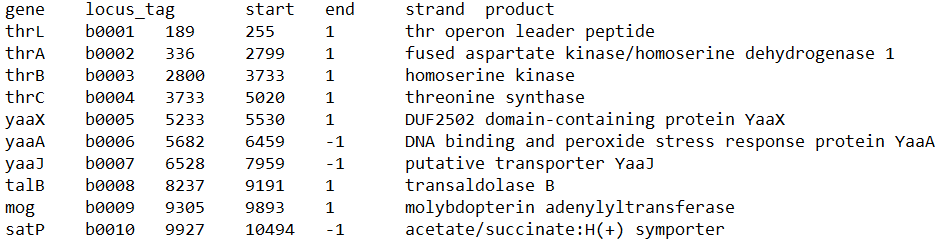

**gene** - название гена

**locus_tag** - уникальный идентификатор гена в геноме

**start/end** - координаты начала и конца гена

**strand** - направление транскрипции гена

**product** - описание белка, кодируемого геном

По полученным данным аннотировали SNP c помощью
> "snp_analysis_fixed.py" - скрипт

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Seq import Seq
import gzip

# загрузка SNP файла (NUCMER)
rows = []

with open("../results/ecoli_full_filt1_snps.tsv") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        if line.startswith("NUCMER"):
            continue

        parts = line.split()

        if len(parts) > 0 and parts[0] in ["[P1]", "P1"]:
            continue

        if len(parts) < 9:
            continue

        try:
            int(parts[0])
        except:
            continue

        rows.append([
            parts[0],  # P1
            parts[1],  # REF
            parts[2],  # ALT
            parts[3],  # P2
            parts[4],  # BUFF
            parts[5],  # DIST
            parts[6],  # FRM
            parts[7],  # TAG1
            parts[8]   # TAG2
        ])

snps = pd.DataFrame(rows, columns=[
    "P1", "REF", "ALT", "P2",
    "BUFF", "DIST", "FRM",
    "TAG1", "TAG2"
])

snps["P1"] = snps["P1"].astype(int)

# фильтр SNP (indels с "." исключаем)
snps = snps[snps["ALT"] != "."]

# загрузка генов
genes_df = pd.read_csv("../results/genes_table.tsv", sep="\t")

genes_df["start"] = genes_df["start"].astype(int)
genes_df["end"] = genes_df["end"].astype(int)
genes_df["strand"] = genes_df["strand"].astype(int)

# загрузка генома GenBank
with gzip.open("../data/ecoli_k12.gbff.gz", "rt") as handle:
    record = SeqIO.read(handle, "genbank")

genome_seq = record.seq


def translate_codon(codon):
    return str(Seq(codon).translate())


results = []

for _, snp in snps.iterrows():

    pos = snp["P1"] - 1

    gene_hit = genes_df[
        (genes_df["start"] <= pos) &
        (genes_df["end"] > pos)
    ]

    if gene_hit.empty:
        results.append({
            "pos": snp["P1"],
            "gene": "intergenic",
            "type": "intergenic",
            "aa_change": "-",
            "effect": "non-coding"
        })
        continue

    gene_row = gene_hit.iloc[0]
    gene = gene_row["gene"]
    start = gene_row["start"]
    end = gene_row["end"]
    strand = gene_row["strand"]

    if strand == 1:
        cds_pos = pos - start
    else:
        cds_pos = end - pos - 1

    codon_pos = cds_pos // 3
    codon_start = start + codon_pos * 3

    codon = genome_seq[codon_start:codon_start + 3]

    if strand == -1:
        codon = codon.reverse_complement()

    codon = list(str(codon))

    codon_index = cds_pos % 3

    mutated_codon = codon.copy()
    mutated_codon[codon_index] = snp["ALT"]

    aa_ref = translate_codon("".join(codon))
    aa_alt = translate_codon("".join(mutated_codon))

    aa_pos = codon_pos + 1

    if aa_ref == aa_alt:
        snp_type = "synonymous"
        effect = "low"
    else:
        snp_type = "nonsynonymous"
        effect = "moderate"

    results.append({
        "pos": snp["P1"],
        "gene": gene,
        "type": snp_type,
        "aa_change": f"p.{aa_ref}{aa_pos}{aa_alt}",
        "effect": effect
    })

annotated = pd.DataFrame(results)

annotated.to_csv("../results/snps_annotated.tsv", sep="\t", index=False)

# топ-10 генов
top_genes = (
    annotated[annotated["gene"] != "intergenic"]
    .groupby("gene")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_genes.to_csv("../results/top_genes.tsv", sep="\t")

# SNP density
plt.figure(figsize=(14, 6))

plt.hist(annotated["pos"], bins=100, alpha=0.6, label="SNP density")

for _, g in genes_df.iterrows():
    plt.axvspan(g["start"], g["end"], color = "lightblue", alpha=0.08)

# легенда-обманка (чтобы гены были видны в legend)
plt.plot([], [], color="lightblue", alpha=0.3, linewidth=10, label="Genes")

plt.title("SNP density with gene regions")
plt.xlabel("Position")
plt.ylabel("Count")

plt.legend()

plt.tight_layout()

plt.savefig("../results/snp_density.png")
plt.close()# распределение типов SNP
plt.figure(figsize=(7, 5))

type_counts = annotated["type"].value_counts()

colors = {
    "synonymous": "#4CAF50",
    "nonsynonymous": "#F44336",
    "intergenic": "#9E9E9E"
}

bars = plt.bar(
    type_counts.index,
    type_counts.values,
    color=[colors.get(x, "blue") for x in type_counts.index]
)

plt.title("SNP type distribution")
plt.ylabel("Count")

plt.xticks(rotation=0)

# короткие подписи
plt.gca().set_xticklabels([
    "Synonymous",
    "Nonsynonymous",
    "Intergenic"
])

plt.tight_layout()

plt.savefig("../results/impact_distribution.png", dpi=300)
plt.close()
print("Analysis completed!")


Скрипт загружает SNP файл, загружает аннотацию генов (GenBank файл E. coli K-12), а также использует созданный файл "genes_table.tsv". В результате работы скрипта получены файлы:


> 1. "snps_annotated.tsv"

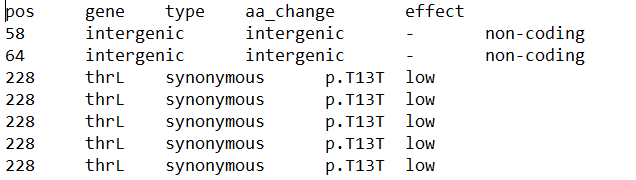

...

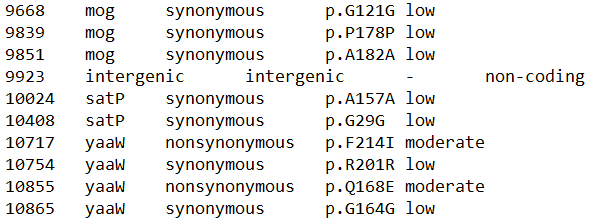

...

Это основной файл, содержащий аннотацию SNP.

**pos** - позиция SNP в референсном геноме

**gene** - в каком гене находится SNP (или же в межгенном регионе)

**type** - тип мутации (synonymous - без изменений аминокислоты, nonsynonymous - с изменением аминокислоты, intergenic - если SNP в некодирующей области).

**aa_change** - изменение аминокислоты

**effect** Оценка функционального эффекта мутации: low — синонимичные замены, moderate — несинонимичные замены, non-coding — межгенные области.

> 2. "top_genes.tsv" - топ-10 генов с наибольшим количеством SNP

In [1]:
import pandas as pd

df = pd.read_csv("top_genes.tsv", sep="\t")
df

,gene,0
0,ybgQ,435
1,yeeJ,250
2,ybgO,223
3,yehI,191
4,ybgP,172
5,ydbA,165
6,yjgL,142
7,yfaL,140
8,entF,131
9,cpsB,122


In [3]:
import pandas as pd

data = [
    ["ybgQ", "b0718", 749721, 752169, -1, "putative fimbrial usher protein YbgQ"],
    ["yeeJ", "b1978", 2044994, 2052014, 1, "inverse autotransporter adhesion"],
    ["ybgO", "b0716", 747920, 748982, -1, "putative fimbrial protein YbgO"],
    ["yehI", "b2118", 2200278, 2203911, 1, "DUF4132 domain-containing protein YehI"],
    ["ybgP", "b0717", 748978, 749707, -1, "putative fimbrial chaperone YbgP"],
    ["ydbA", "b4492", 1465391, 1474013, 1, "putative outer membrane protein, N-terminal fragment"],
    ["yigL", "b3826", 4010199, 4011000, 1, "phosphosugar phosphatase YigL"],
    ["yfaL", "b2233", 2340416, 2344169, -1, "putative autotransporter adhesin YfaL"],
    ["entF", "b0586", 614156, 618038, 1, "apo-serine activating enzyme"],
    ["cpsB", "b2049", 2123083, 2124520, -1, "mannose-1-phosphate guanylyltransferase"]
]

df = pd.DataFrame(
    data,
    columns=[
        "gene",
        "locus_tag",
        "start",
        "end",
        "strand",
        "product"
    ]
)

df

,gene,locus_tag,start,end,strand,product
0,ybgQ,b0718,749721,752169,-1,putative fimbrial usher protein YbgQ
1,yeeJ,b1978,2044994,2052014,1,inverse autotransporter adhesion
2,ybgO,b0716,747920,748982,-1,putative fimbrial protein YbgO
3,yehI,b2118,2200278,2203911,1,DUF4132 domain-containing protein YehI
4,ybgP,b0717,748978,749707,-1,putative fimbrial chaperone YbgP
5,ydbA,b4492,1465391,1474013,1,"putative outer membrane protein, N-terminal fr..."
6,yigL,b3826,4010199,4011000,1,phosphosugar phosphatase YigL
7,yfaL,b2233,2340416,2344169,-1,putative autotransporter adhesin YfaL
8,entF,b0586,614156,618038,1,apo-serine activating enzyme
9,cpsB,b2049,2123083,2124520,-1,mannose-1-phosphate guanylyltransferase


In [4]:
import pandas as pd

data = [
    ["ybgQ", "fimbriae / assembly", 749721, 752169, -1, "putative fimbrial usher protein YbgQ"],
    ["yeeJ", "adhesion (autotransporter)", 2044994, 2052014, 1, "inverse autotransporter adhesion"],
    ["ybgO", "fimbriae / structural", 747920, 748982, -1, "putative fimbrial protein YbgO"],
    ["yehI", "outer membrane / DUF protein", 2200278, 2203911, 1, "DUF4132 domain-containing protein YehI"],
    ["ybgP", "fimbriae / assembly (chaperone)", 748978, 749707, -1, "putative fimbrial chaperone YbgP"],
    ["ydbA", "outer membrane protein", 1465391, 1474013, 1, "putative outer membrane protein, N-terminal fragment"],
    ["yigL", "metabolism (sugar phosphatase)", 4010199, 4011000, 1, "phosphosugar phosphatase YigL"],
    ["yfaL", "adhesion (autotransporter)", 2340416, 2344169, -1, "putative autotransporter adhesin YfaL"],
    ["entF", "metabolism (siderophore synthesis)", 614156, 618038, 1, "apo-serine activating enzyme"],
    ["cpsB", "cell surface / polysaccharide metabolism", 2123083, 2124520, -1, "mannose-1-phosphate guanylyltransferase"]
]

df = pd.DataFrame(
    data,
    columns=["gene", "function_group", "start", "end", "strand", "product"]
)

# длина гена
df["gene_length_bp"] = df["end"] - df["start"] + 1

df

,gene,function_group,start,end,strand,product,gene_length_bp
0,ybgQ,fimbriae / assembly,749721,752169,-1,putative fimbrial usher protein YbgQ,2449
1,yeeJ,adhesion (autotransporter),2044994,2052014,1,inverse autotransporter adhesion,7021
2,ybgO,fimbriae / structural,747920,748982,-1,putative fimbrial protein YbgO,1063
3,yehI,outer membrane / DUF protein,2200278,2203911,1,DUF4132 domain-containing protein YehI,3634
4,ybgP,fimbriae / assembly (chaperone),748978,749707,-1,putative fimbrial chaperone YbgP,730
5,ydbA,outer membrane protein,1465391,1474013,1,"putative outer membrane protein, N-terminal fr...",8623
6,yigL,metabolism (sugar phosphatase),4010199,4011000,1,phosphosugar phosphatase YigL,802
7,yfaL,adhesion (autotransporter),2340416,2344169,-1,putative autotransporter adhesin YfaL,3754
8,entF,metabolism (siderophore synthesis),614156,618038,1,apo-serine activating enzyme,3883
9,cpsB,cell surface / polysaccharide metabolism,2123083,2124520,-1,mannose-1-phosphate guanylyltransferase,1438


В данной выборке наблюдается преобладание генов, кодирующих белки, связанные с внешними структурами бактериальной клетки (+ для них преимущественно выше число SNP).


- **YbgQ, YbgO, YbgP** — компоненты системы фимбрий (usher, structural protein, chaperone), участвующие в сборке и формировании поверхностных адгезивных структур  
- **YeeJ, YfaL** — автотранспортеры и адгезины, связанные с прикреплением к поверхности и взаимодействием с окружающей средой  
- **YdbA, YehI** — белки внешней мембраны или мембрано-ассоциированные белки

Высокое количество SNP в данных генах может быть связано с механизмами адаптации бактерий. Иммунная система реагирует на поверхностные белки бактерий, поэтому мутации в них могут служить защитой от распознования. С другой стороны, изменения в поверхностных белках могут служить способом приспособления к новой среде/изменениям внешей среды.




> 3. "snp_density.png" - график плотности SNP с наложением позиций генов

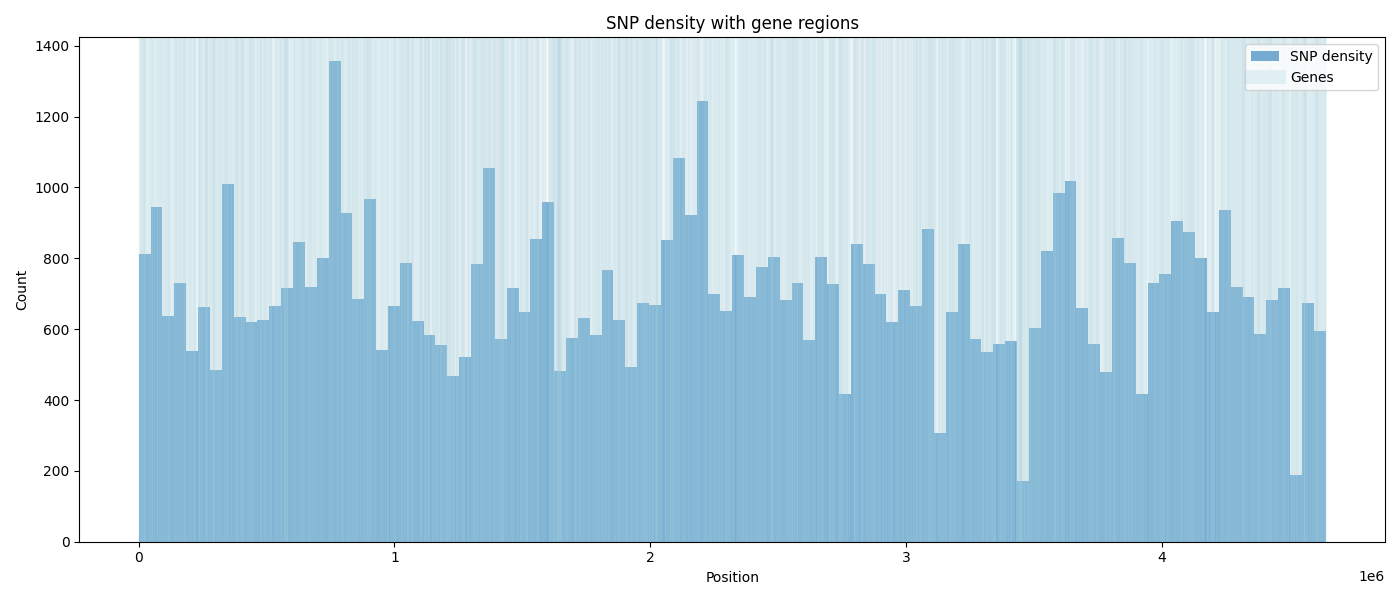

> 4. "impact_distribution.png" - диаграмма распределения типов SNP (синонимичные/несинонимичные).



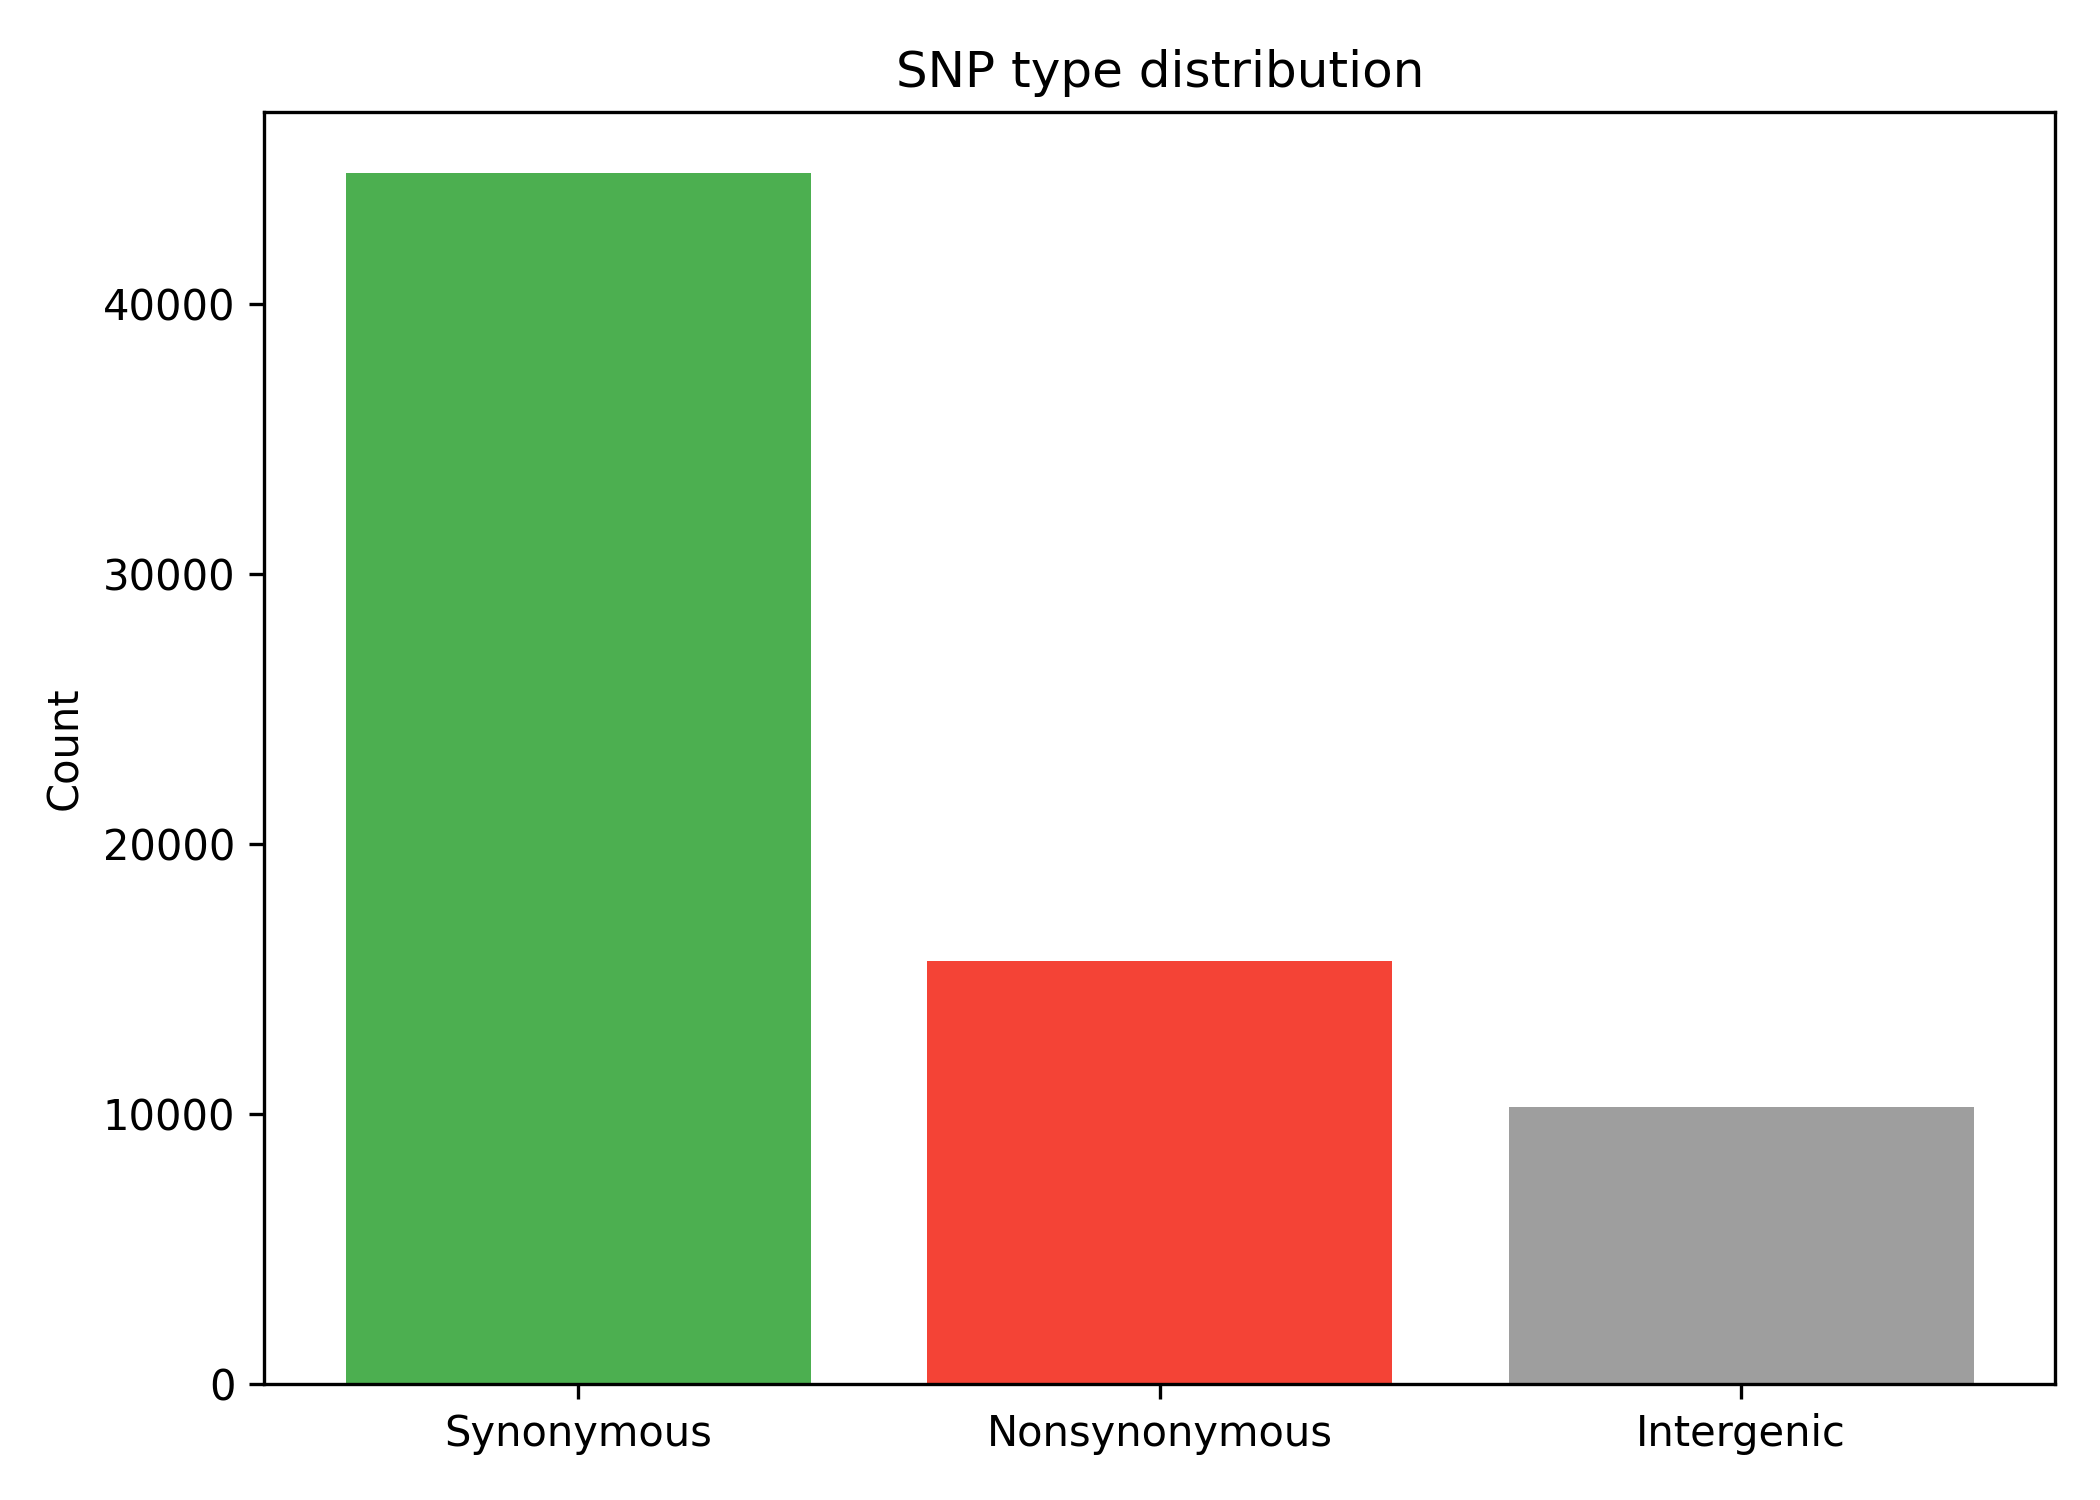

Из диаграммы можно сделать вывод, что преобладают SNP без изменения аминокислоты и соответсвенно без функциональных изменений. Наименьшее количество SNP приходится на некодирующие области.

#  Часть 3 — Поиск функционально значимых SNP


В продолжение анализа интересно рассмотреть мутации в генах устойчивости бактерий к тяжелым металлам и биоцидам.

Информация по данной теме взята из статьи:
> Геномные мутации в E. coli от экспозиции тяжелым металлам (As, Cd, Cr, Cu, Ni, Pb): https://pmc.ncbi.nlm.nih.gov/articles/PMC11137339/

**Гены устойчивости к тяжёлым металлам:**

В рамках анализа были выбраны гены Escherichia coli, ассоциированные с устойчивостью к различным тяжёлым металлам, на основе данных статьи.

**Медь (Cu):** nusA, pagP, atpC, dpiA, tatE, dpiB

**Кадмий (Cd):** hflB, araG, napB, araH  

**Свинец (Pb):** chaB, lolD  

**Хром (Cr):** nepI  

Мутации в этих генах связаны с путями биосорбции, внеклеточного осаждения и внеклеточного выведения, которые могут способствовать устойчивости микроорганизмов к металлам

Выявленные SNP были сопоставлены с перечнем генов устойчивости к тяжёлым металлам. Для каждого гена было подсчитано количество SNP, попадающих в его координаты.

Далее гены были сгруппированы по типу металла, к которому они относятся (Cu, Cd, Pb, Cr)



> "functional_snps_final.py" - скрипт

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

snps = pd.read_csv("../results/snps_annotated.tsv", sep="\t")
genes_table = pd.read_csv("../results/genes_table.tsv", sep="\t")

metal_genes = {
    "Cu": ["nusA", "pagP", "atpC", "dpiA", "tatE", "dpiB"],
    "Cd": ["hflB", "araG", "napB", "araH"],
    "Pb": ["chaB", "lolD"],
    "Cr": ["nepI"]
}

gene_to_metal = {
    gene: metal
    for metal, genes in metal_genes.items()
    for gene in genes
}

snps = snps[snps["gene"].isin(gene_to_metal.keys())].copy()
snps["metal"] = snps["gene"].map(gene_to_metal)

snps = snps.merge(
    genes_table[["gene", "product"]],
    on="gene",
    how="left"
)

print("SNPs per gene")
print(snps["gene"].value_counts())

print("SNPs per metal")
print(snps["metal"].value_counts())

if "type" in snps.columns:
    print("SNP effect distribution")
    print(snps["type"].value_counts())

snps.to_csv("../results/part3_functional_snps.tsv", sep="\t", index=False)

plt.figure(figsize=(8, 5))
snps["gene"].value_counts().plot(kind="bar")
plt.title("SNP distribution across genes")
plt.xlabel("Gene")
plt.ylabel("Number of SNPs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/snp_per_gene.png", dpi=300)
plt.close()

plt.figure(figsize=(6, 4))
snps["metal"].value_counts().plot(kind="bar")
plt.title("SNP distribution by metal category")
plt.xlabel("Metal")
plt.ylabel("Number of SNPs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/snp_per_metal.png", dpi=300)
plt.close()

plt.figure(figsize=(10, 5))
snps["product"].value_counts().head(10).plot(kind="bar")
plt.title("Top affected protein functions")
plt.xlabel("Protein function")
plt.ylabel("Number of SNPs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../results/snp_per_product.png", dpi=300)
plt.close()

summary = snps.groupby(["gene", "metal", "product"]).size().reset_index(name="SNP_count")
summary.to_csv("../results/part3_summary_table.tsv", sep="\t", index=False)

print("Analysis completed")


Результаты работы скрипта представленны в файлах:

> 1. "part3_functional_snps.tsv"

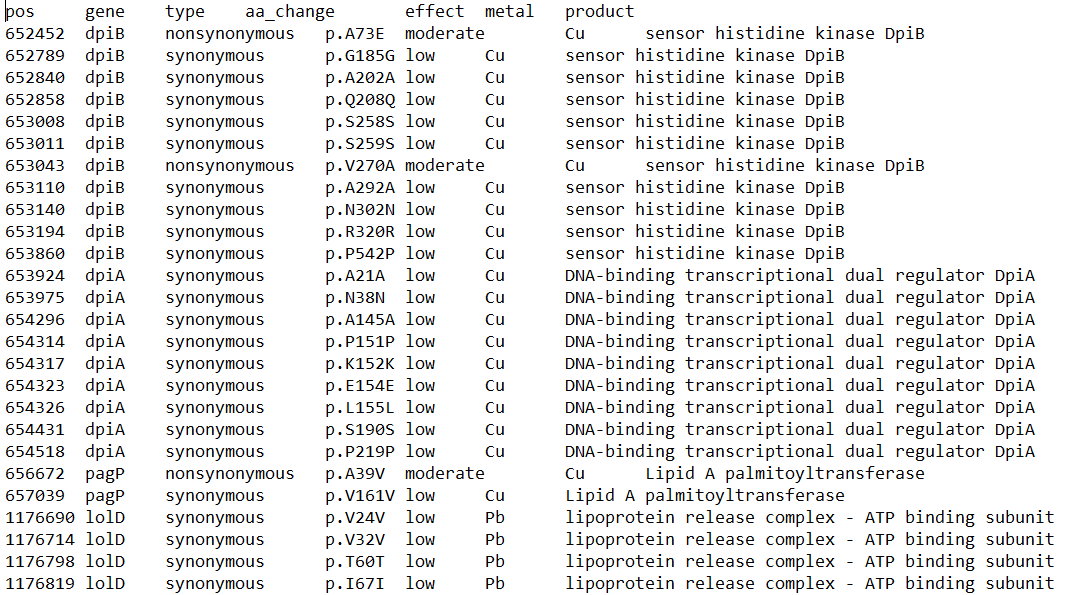

Данный файл содержит информацию о положении SNP; принадлженость гену устойчивости; название металла с которым ассоциирован ген; изменение аминокислоты; тип мутации; а также информация о продукте реализации гена.

> 2. "part3_summary_table.tsv"

In [2]:
df_1 = pd.read_csv("part3_summary_table.tsv", sep="\t")
df_1

,gene,metal,product,SNP_count
0,araG,Cd,arabinose ABC transporter ATP binding subunit,17
1,araH,Cd,arabinose ABC transporter membrane subunit,22
2,atpC,Cu,ATP synthase F1 complex subunit epsilon,1
3,chaB,Pb,putative cation transport regulator ChaB,1
4,dpiA,Cu,DNA-binding transcriptional dual regulator DpiA,9
5,dpiB,Cu,sensor histidine kinase DpiB,11
6,lolD,Pb,lipoprotein release complex - ATP binding subunit,20
7,napB,Cd,periplasmic nitrate reductase cytochrome c550 ...,2
8,nepI,Cr,purine ribonucleoside exporter,68
9,nusA,Cu,transcription termination/antitermination prot...,9


> 3. "snp_per_gene.png"

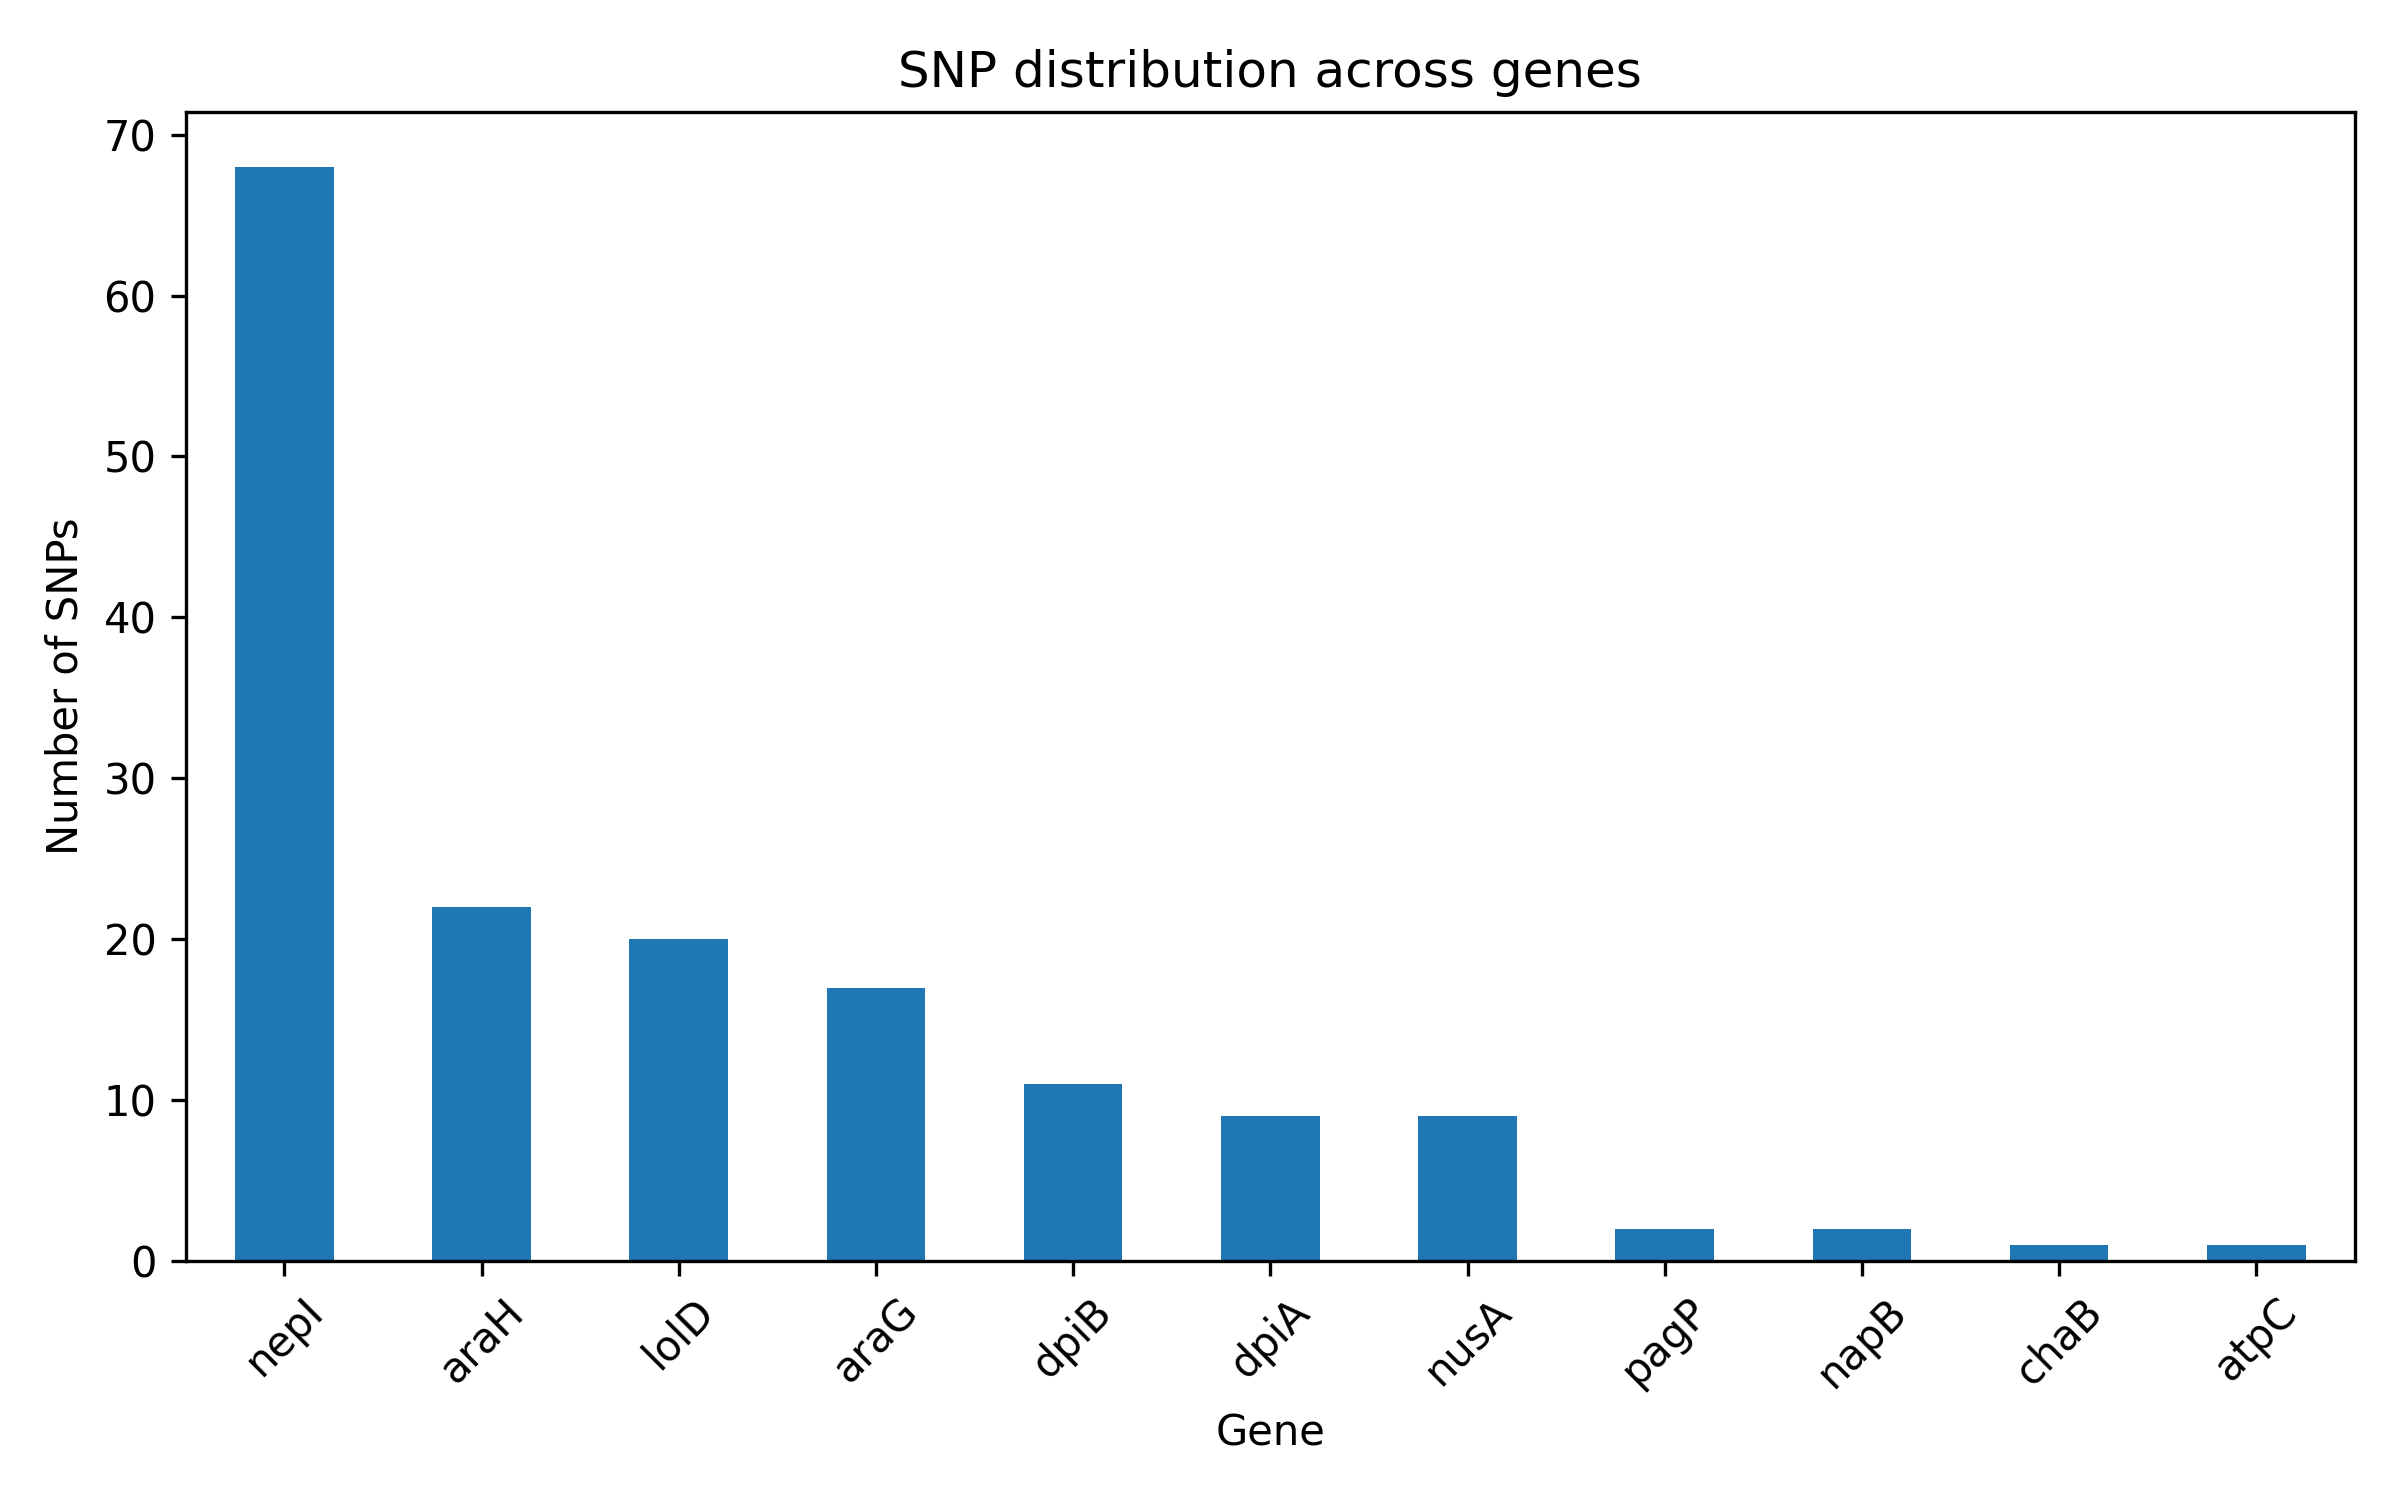

> 4. "snp_per_metal.png"

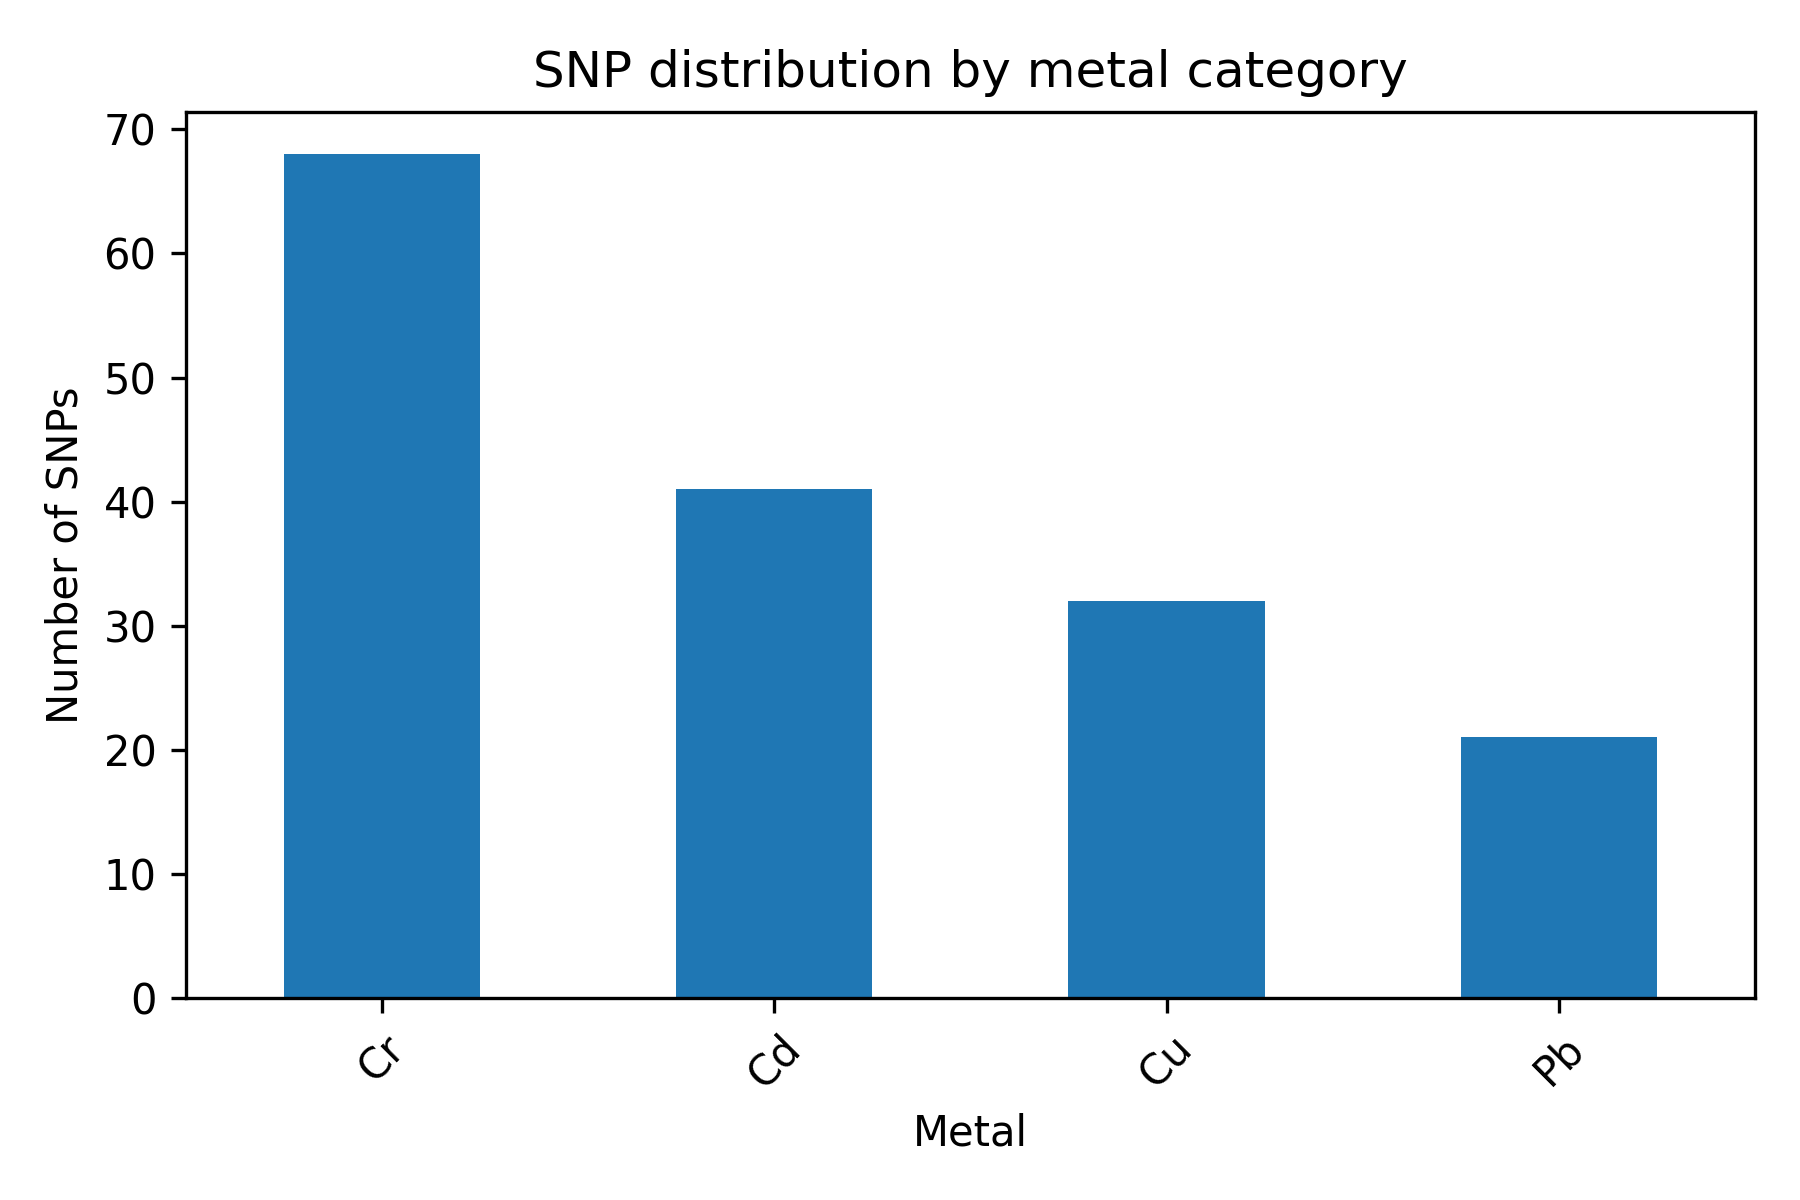

> 5. "snp_per_product.png"

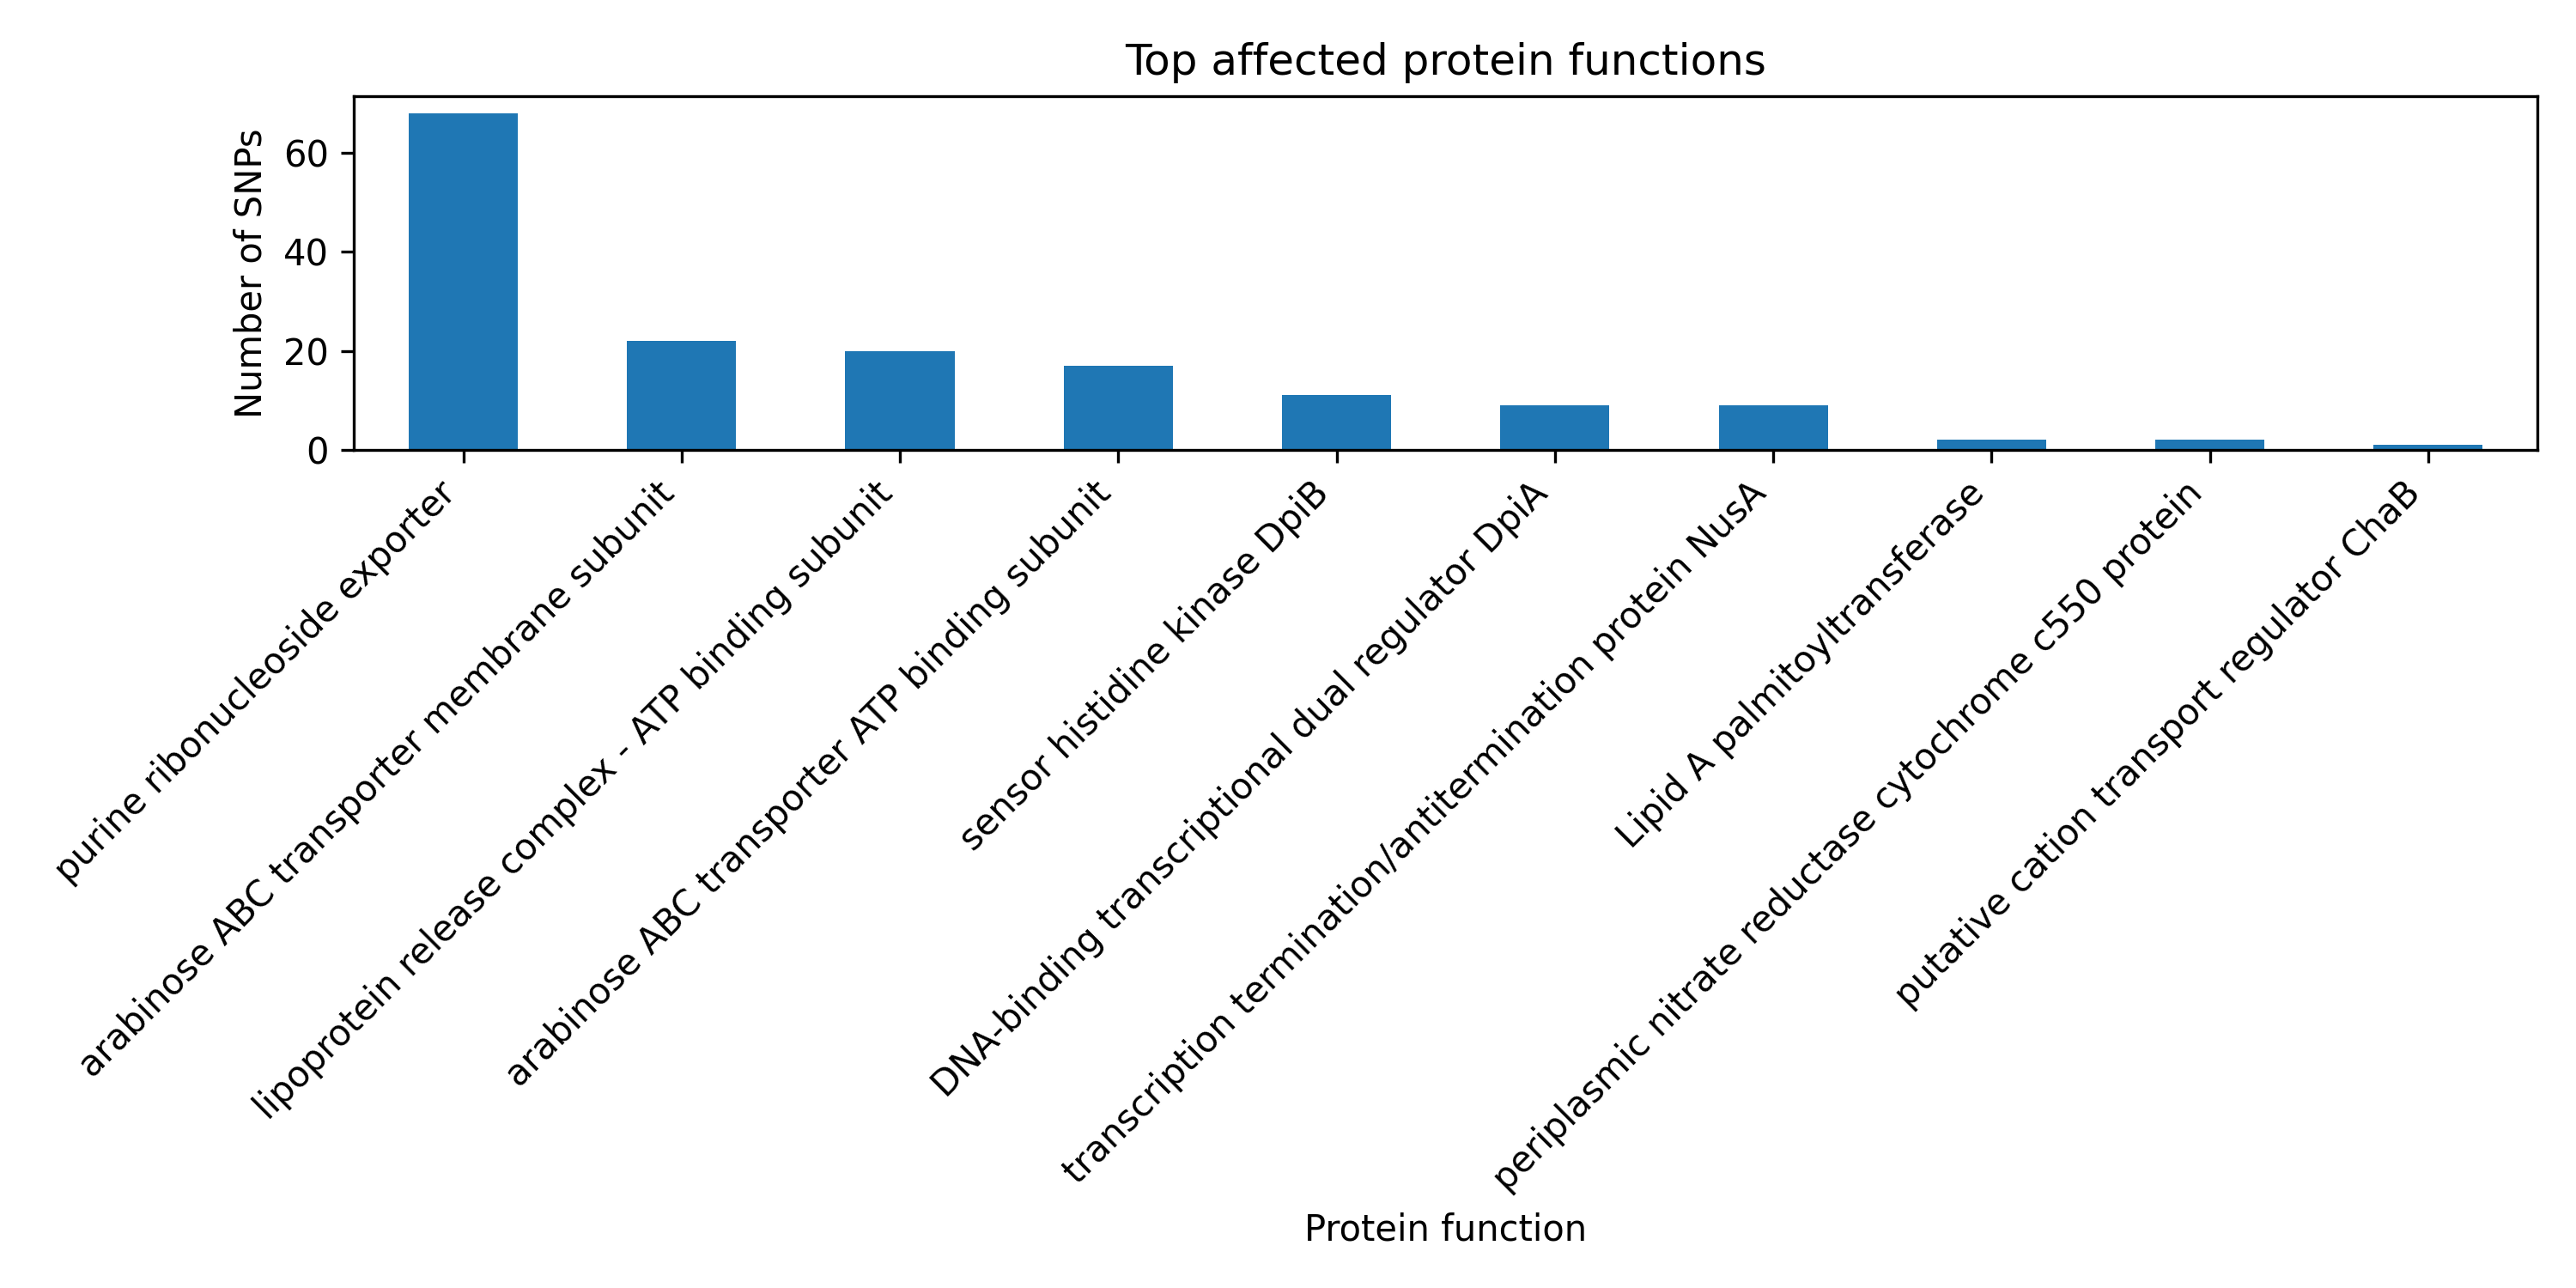



Наибольшее количество SNP наблюдается в гене, связанном с устойчивостью к Cr. Изменения затрагивают белок-экспортер, что указывает на усиление выведения металла из клетки. Для Cd также характерно повышенное число SNP, преимущественно в транспортных белках, что отражает адаптацию через системы транспорта. В случае Cu уровень количество SNP ниже, а затронутые гены связаны с регуляцией транскрипции и модификацией мембраны (например, pagP). Для Pb наблюдается относительно небольшое число SNP (минимальное по сумме из представленных), при этом соответствующие белки участвуют в мембранном транспорте и липопротеиновых системах, что может быть связано с барьерной функцией клетки.

**Как можно применить результаты этого анализа в реальной жизни?**


1. > HMRG в E. coli (cutF/nlpE, robA и др.), часто ко-локализованы с ARGs:  [Study of heavy metal resistance genes in Escherichia coli isolates from a marine ecosystem with a history of environmental pollution (arsenic, cadmium, copper, and mercury) | PLOS One ](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0294565)

Одно их применений результатов поиска функционально значимых SNP в генах устойчивости к тяжелым металлам - продолжение исследований.

Приведенная выше статья посвещена изучению взаимосвязи генов устойчивости к тяжелым металлам (HMRG) и генов устойчивости к антибиотикам (ARG). Механизмы адаптации (например, транспорт и регуляция) бактерий к воздействию тяжелых металлов могут также быть эффективны для развития антибиотикорезистентности. Изучение данной темы выявило потенциальные угрозы распространения устойчивости к антибиотикам со стороны загрязнения окружающей среды тяжелыми металлами.

Выявленные взаимосвязи генов HMRG и ARG могут быть полезны для изучения механизмов антибиотикорезистентности бактерий.

2. Можно анализировать уровень загрязнения почв/водоемов тяжелыми металлами, а также идентифицировать преобладающие металлы по количеству и позиции в геноме бактерий SNP.

3. Так как воздействие конкретных типов тяжелых металлов вызывает функциональные изменения в продуктах реализации генома. Можно намеренно помещать бактерии в среду с повышенным содержанием металла для получения нужных мутаций и продуктов в результате. Такой подход может использоваться для решения биотехнологических задач.